## 1. Hangi kategori hem ticari performans hem de müşteri memnuniyeti açısından en güçlü görünüyor?


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()
pd.set_option('display.max_columns', None)

In [ ]:
df = pd.read_csv("/content/e_ticaret_veri_seti_aykiri_degerler_duzenlendi.csv")
df.head()

,siparis_id,musteri_id,siparis_tarihi,sehir,bolge,kategori,urun_adi,adet,birim_fiyat,indirim_orani,kargo_ucreti,odeme_turu,musteri_tipi,teslimat_gunu,musteri_puani,iade_durumu,kar_marji_orani,toplam_tutar,siparis_yili,siparis_ayi,siparis_gunu,haftanin_gunu
0,SIP101125,MUS1391,2024-01-13 17:06:00,İstanbul,Marmara,Kozmetik,Nemlendirici,1,414.51,0.05,49.9,Kredi Kartı,Yeni,3.0,5.0,Hayır,0.220,443.68,2024,1,13,Saturday
1,SIP100263,MUS1008,2024-08-10 15:13:00,Antalya,Akdeniz,Kitap,Girişimcilik,5,194.78,0.00,49.9,Kapıda Ödeme,Yeni,3.0,5.0,Hayır,0.250,1023.80,2024,8,10,Saturday
2,SIP100707,MUS1291,2024-08-19 08:24:00,Gaziantep,Güneydoğu Anadolu,Elektronik,Powerbank,3,841.80,0.05,39.9,Dijital Cüzdan,Mevcut,4.0,5.0,Hayır,0.280,2439.03,2024,8,19,Monday
3,SIP100687,MUS1147,2025-08-09 08:42:00,Konya,İç Anadolu,Kozmetik,Nemlendirici,2,417.02,0.00,59.9,Dijital Cüzdan,Mevcut,4.0,5.0,Hayır,0.220,893.94,2025,8,9,Saturday
4,SIP100254,MUS1447,2024-07-30 09:06:00,Konya,İç Anadolu,Elektronik,Bluetooth Hoparlör,1,1327.75,0.05,29.9,Banka Kartı,Mevcut,4.0,5.0,Hayır,0.283,1291.26,2024,7,30,Tuesday


### Kategori bazında sipariş sayısı, toplam gelir, ortalama sipariş tutarı, ortalama müşteri puanı ve ortalama teslimat günü metriklerini çıkarın.

In [ ]:
kategori_analizi = (
    df.groupby('kategori')
    .agg(
        siparis_sayisi          = ('siparis_id', 'count'),
        toplam_gelir            = ('toplam_tutar', 'sum'),
        ortalama_siparis_tutari = ('toplam_tutar','mean'),
        ortalama_musteri_puani  = ('musteri_puani', 'mean'),
        ortalama_teslimat_gunu =  ('teslimat_gunu','mean')
    )
    .round(2)
    .sort_values('toplam_gelir', ascending=False)
    .reset_index()
)

### Kategori bazlı özet tablo oluşturun.

In [ ]:
kategori_analizi

,kategori,siparis_sayisi,toplam_gelir,ortalama_siparis_tutari,ortalama_musteri_puani,ortalama_teslimat_gunu
0,Elektronik,140,212930.29,1520.93,4.24,3.32
1,Spor,186,189481.91,1018.72,4.26,3.18
2,Kozmetik,200,147522.90,737.61,4.42,3.35
3,Ev Yaşam,184,142335.55,773.56,4.26,3.45
4,Kitap,223,114075.59,511.55,4.25,3.42
5,Ofis,162,47051.88,290.44,4.24,3.13


### Toplam gelir için bir bar plot çizdirin.

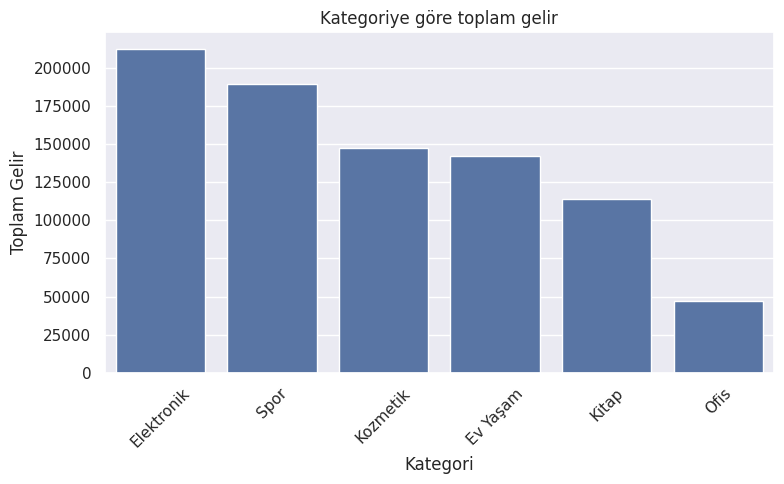

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=kategori_analizi,
            x='kategori',
            y='toplam_gelir',
            )
plt.title("Kategoriye göre toplam gelir")
plt.xlabel("Kategori")
plt.ylabel('Toplam Gelir')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Ortalama müşteri puanı için ikinci bir bar plot çizdirin.

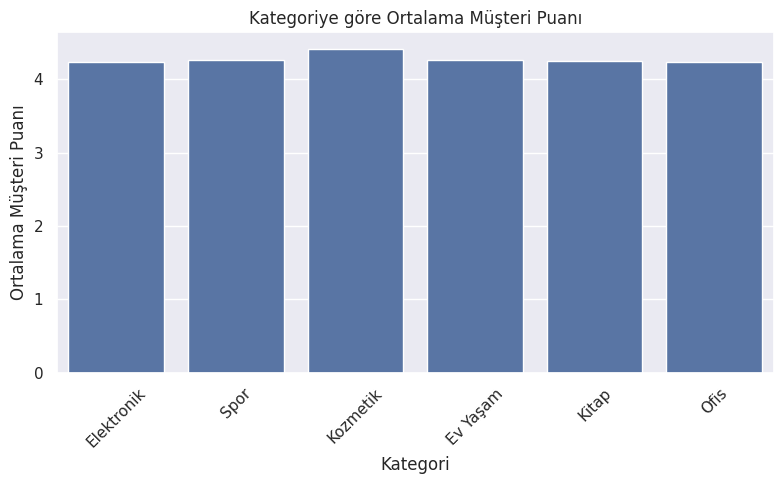

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=kategori_analizi,
            x='kategori',
            y='ortalama_musteri_puani',
            )
plt.title("Kategoriye göre Ortalama Müşteri Puanı")
plt.xlabel("Kategori")
plt.ylabel('Ortalama Müşteri Puanı')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Hem gelir hem memnuniyet açısından en güçlü kategoriyi belirleyin ve kısa bir iş yorumu yazın.

In [ ]:
print(kategori_analizi.iloc[0])
kategori_analizi

kategori                   Elektronik
siparis_sayisi                    140
toplam_gelir                212930.29
ortalama_siparis_tutari       1520.93
ortalama_musteri_puani           4.24
ortalama_teslimat_gunu           3.32
Name: 0, dtype: object


,kategori,siparis_sayisi,toplam_gelir,ortalama_siparis_tutari,ortalama_musteri_puani,ortalama_teslimat_gunu
0,Elektronik,140,212930.29,1520.93,4.24,3.32
1,Spor,186,189481.91,1018.72,4.26,3.18
2,Kozmetik,200,147522.90,737.61,4.42,3.35
3,Ev Yaşam,184,142335.55,773.56,4.26,3.45
4,Kitap,223,114075.59,511.55,4.25,3.42
5,Ofis,162,47051.88,290.44,4.24,3.13


## 2. Hangi şehirler daha yüksek potansiyel taşıyor?


### Şehir bazında sipariş sayısı, toplam gelir, ortalama sipariş tutarı ve ortalama müşteri puanı metriklerini çıkarın.

In [ ]:
sehir_analizi = (
    df.groupby('sehir')
    .agg(
        siparis_sayisi          = ('siparis_id', 'count'),
        toplam_gelir            = ('toplam_tutar', 'sum'),
        ortalama_siparis_tutari = ('toplam_tutar','mean'),
        ortalama_musteri_puani  = ('musteri_puani', 'mean'),
        ortalama_teslimat_gunu =  ('teslimat_gunu','mean')
    )
    .round(2)
    .reset_index()
)

### Şehir bazlı özet tablo oluşturun.

In [ ]:
sehir_analizi

,sehir,siparis_sayisi,toplam_gelir,ortalama_siparis_tutari,ortalama_musteri_puani,ortalama_teslimat_gunu
0,Adana,63,50353.28,799.26,4.33,3.46
1,Ankara,124,96721.13,780.01,4.19,3.10
2,Antalya,86,63712.80,740.85,4.28,3.49
3,Bursa,67,46782.83,698.25,4.21,3.51
4,Eskişehir,45,37550.04,834.45,4.24,3.16
5,Gaziantep,49,35240.29,719.19,4.35,3.43
6,Kayseri,36,24878.81,691.08,4.28,3.61
7,Kocaeli,31,21293.02,686.87,4.19,3.29
8,Konya,77,59424.33,771.74,4.36,3.31
9,Mersin,46,38043.87,827.04,4.22,3.46


### Toplam gelire göre şehirleri büyükten küçüğe sıralayın.

In [ ]:
sehir_analizi = sehir_analizi.sort_values('toplam_gelir', ascending=False)
sehir_analizi

,sehir,siparis_sayisi,toplam_gelir,ortalama_siparis_tutari,ortalama_musteri_puani,ortalama_teslimat_gunu
12,İstanbul,264,224020.57,848.56,4.36,3.30
1,Ankara,124,96721.13,780.01,4.19,3.10
13,İzmir,118,88718.51,751.85,4.18,3.13
2,Antalya,86,63712.80,740.85,4.28,3.49
8,Konya,77,59424.33,771.74,4.36,3.31
0,Adana,63,50353.28,799.26,4.33,3.46
3,Bursa,67,46782.83,698.25,4.21,3.51
9,Mersin,46,38043.87,827.04,4.22,3.46
4,Eskişehir,45,37550.04,834.45,4.24,3.16
10,Samsun,45,36263.46,805.85,4.44,3.27


### En güçlü 5 şehir için bir bar plot çizdirin.

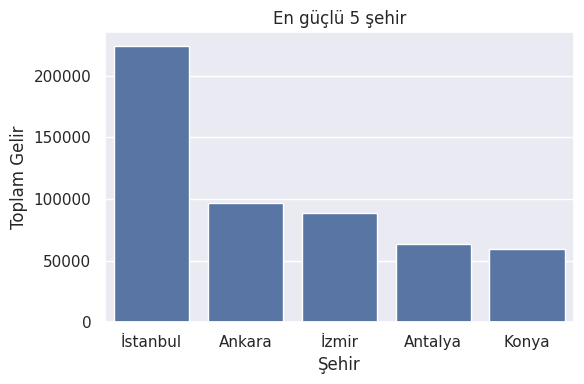

In [ ]:
en_guclu_5_sehir = sehir_analizi.head()
# en_guclu_5_sehir

plt.figure(figsize=(6,4))
sns.barplot(data=en_guclu_5_sehir,
            x='sehir',
            y='toplam_gelir',
            )
plt.title("En güçlü 5 şehir")
plt.xlabel("Şehir")
plt.ylabel('Toplam Gelir')
# plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Müşteri puanı yüksek ama gelir açısından geride kalan şehirleri ayrıca tespit edin ve büyüme adayı şehirler için kısa bir yorum yazın.

In [ ]:
# sehir_analizi.sort_values('ortalama_musteri_puani', ascending=False)
# sehir_analizi

buyume_adayi_sehirler = sehir_analizi[
    (sehir_analizi['ortalama_musteri_puani'] > sehir_analizi['ortalama_musteri_puani'].mean()) &
    (sehir_analizi['toplam_gelir'] < sehir_analizi['toplam_gelir'].mean())
]
buyume_adayi_sehirler.sort_values('toplam_gelir')
print(f"Müşteri puanının yüksek olduğu büyüme adayı olabilecek şehirler: {buyume_adayi_sehirler.iloc[:3][['sehir']]}")

Müşteri puanının yüksek olduğu büyüme adayı olabilecek şehirler:      sehir
8    Konya
0    Adana
10  Samsun


## 3.  Hangi ödeme türü daha değerli müşteri davranışı üretiyor?


### Ödeme türü bazında sipariş sayısı, toplam gelir, ortalama sipariş tutarı, ortalama müşteri puanı ve ortalama teslimat günü metriklerini çıkarın.

In [ ]:
odeme_türü_analizi = (
    df.groupby('odeme_turu')
    .agg(
        siparis_sayisi          = ('siparis_id', 'count'),
        toplam_gelir            = ('toplam_tutar', 'sum'),
        ortalama_siparis_tutari = ('toplam_tutar','mean'),
        ortalama_musteri_puani  = ('musteri_puani', 'mean'),
        ortalama_teslimat_gunu =  ('teslimat_gunu','mean')
    )
    .round(2)
    .sort_values('toplam_gelir', ascending=False)
    .reset_index()
)

### Ödeme türüne göre özet tablo oluşturun.

In [ ]:
odeme_türü_analizi

,odeme_turu,siparis_sayisi,toplam_gelir,ortalama_siparis_tutari,ortalama_musteri_puani,ortalama_teslimat_gunu
0,Kredi Kartı,583,439468.16,753.80,4.31,3.31
1,Banka Kartı,169,143011.08,846.22,4.24,3.53
2,Dijital Cüzdan,153,129911.25,849.09,4.27,3.27
3,Havale/EFT,111,92894.46,836.89,4.15,3.14
4,Kapıda Ödeme,79,48113.17,609.03,4.38,3.24


### Ortalama sipariş tutarı için bir bar plot çizdirin.

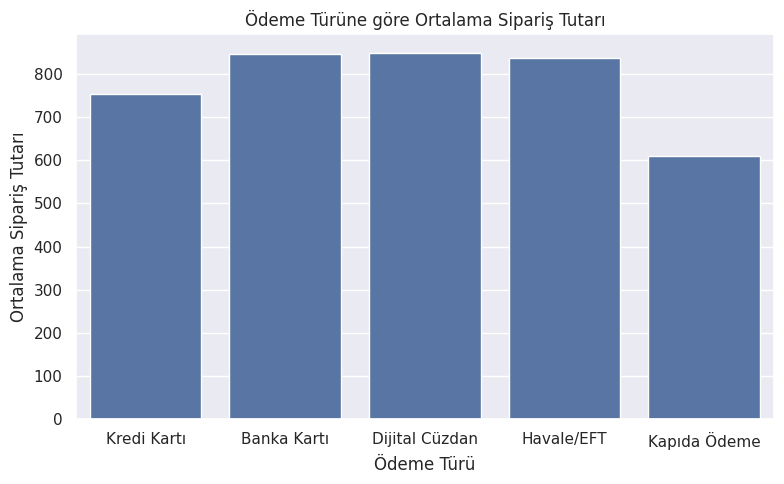

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=odeme_türü_analizi,
            x='odeme_turu',
            y='ortalama_siparis_tutari',
            )
plt.title("Ödeme Türüne göre Ortalama Sipariş Tutarı")
plt.xlabel("Ödeme Türü")
plt.ylabel('Ortalama Sipariş Tutarı')
plt.tight_layout()
plt.show()

### Ortalama müşteri puanı için ikinci bir bar plot çizdirin.

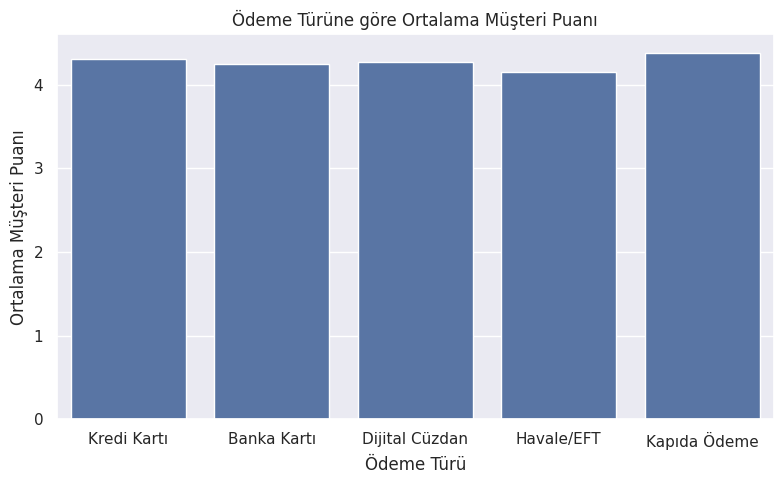

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=odeme_türü_analizi,
            x='odeme_turu',
            y='ortalama_musteri_puani',
            )
plt.title("Ödeme Türüne göre Ortalama Müşteri Puanı")
plt.xlabel("Ödeme Türü")
plt.ylabel('Ortalama Müşteri Puanı')
plt.tight_layout()
plt.show()

### En yüksek gelir üreten ödeme türü ile en yüksek memnuniyet üreten ödeme türünü karşılaştırın ve sonucu iş diliyle yorumlayın.

In [ ]:
# kredi kartı ~ kapıda ödeme ? banka kartı
en_yuksek_getirili_odeme = odeme_türü_analizi.iloc[0]['odeme_turu']
en_yuksek_musteri_memnuniyetli_odeme = odeme_türü_analizi.sort_values('ortalama_musteri_puani',ascending=False).iloc[0]['odeme_turu']
print(f"En yüksek getirisi olan ödeme türü: {en_yuksek_getirili_odeme}")
print(f"En yüksek müşteri memnuniyeti gösteren ödeme türü: {en_yuksek_musteri_memnuniyetli_odeme}")
print(f"Müşterilerin {en_yuksek_musteri_memnuniyetli_odeme} memnuniyeti bozulmadan {en_yuksek_getirili_odeme} ödeme yönteminde memnuniyetin artırılması için aksiyon alınabilir.")

En yüksek getirisi olan ödeme türü: Kredi Kartı
En yüksek müşteri memnuniyeti gösteren ödeme türü: Kapıda Ödeme
Müşterilerin Kapıda Ödeme memnuniyeti bozulmadan Kredi Kartı ödeme yönteminde memnuniyetin artırılması için aksiyon alınabilir.


## 4. Zaman içinde satış davranışı nasıl değişiyor?


### siparis_tarihi sütununu uygun veri tipine dönüştürün.

In [ ]:
df['siparis_tarihi'] = pd.to_datetime(df['siparis_tarihi'])
df['siparis_tarihi'].dtype

dtype('<M8[ns]')

### Ay bazında sipariş sayısı, toplam gelir ve ortalama sipariş tutarı metriklerini çıkarın.

In [ ]:
ay_bazli_analiz = (
    df.groupby(df['siparis_ayi'])
    .agg(
        siparis_sayisi          = ('siparis_id', 'count'),
        toplam_gelir            = ('toplam_tutar', 'sum'),
        ortalama_siparis_tutari = ('toplam_tutar','mean')
        )
    .round(2)
    .sort_values('siparis_ayi', ascending=False)
    .reset_index()
)
ay_bazli_analiz

,siparis_ayi,siparis_sayisi,toplam_gelir,ortalama_siparis_tutari
0,12,97,79366.45,818.21
1,11,86,62337.84,724.86
2,10,89,60860.45,683.83
3,9,91,80591.62,885.62
4,8,80,55945.11,699.31
5,7,79,68774.62,870.56
6,6,85,77526.88,912.08
7,5,102,92213.41,904.05
8,4,111,68630.39,618.29
9,3,94,70857.89,753.81


### Sipariş sayısı için bir line plot çizdirin.

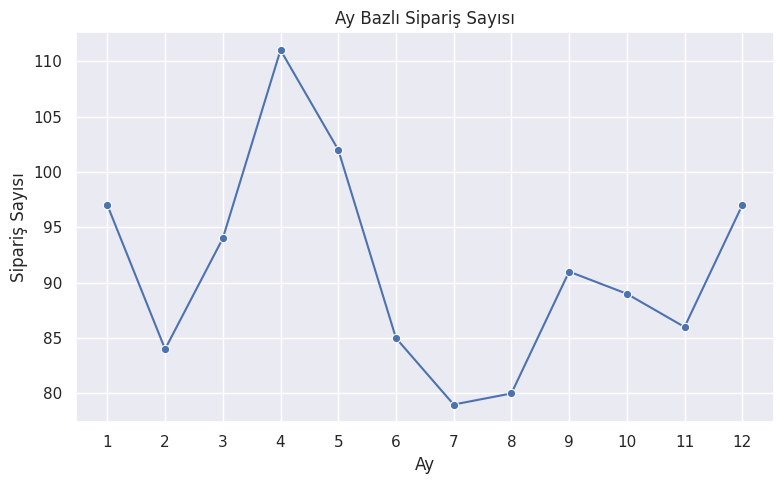

In [ ]:
plt.figure(figsize=(8,5))
sns.lineplot(data=ay_bazli_analiz,
             x='siparis_ayi',
             y='siparis_sayisi',
             marker='o'
             )
plt.title("Ay Bazlı Sipariş Sayısı")
plt.xlabel("Ay")
plt.ylabel('Sipariş Sayısı')
plt.xticks(ay_bazli_analiz['siparis_ayi'])
plt.tight_layout()
plt.show()

### Toplam gelir için ikinci bir line plot çizdirin.

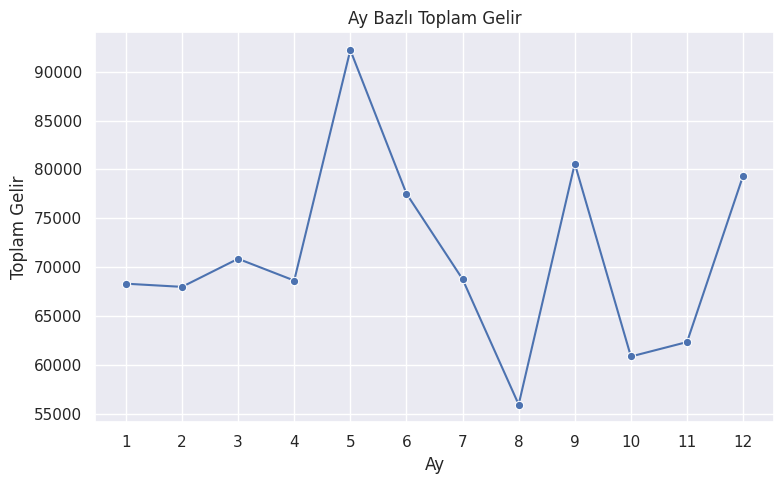

In [ ]:
plt.figure(figsize=(8,5))
sns.lineplot(data=ay_bazli_analiz,
             x='siparis_ayi',
             y='toplam_gelir',
             marker='o'
             )
plt.title("Ay Bazlı Toplam Gelir")
plt.xlabel("Ay")
plt.ylabel('Toplam Gelir')
plt.xticks(ay_bazli_analiz['siparis_ayi'])
plt.tight_layout()
plt.show()

### En yoğun ay ile en yüksek gelir elde edilen ayı karşılaştırın ve “sipariş artışı ile gelir artışı aynı dönemde mi gerçekleşiyor?” sorusuna yorum yapın.

En çok sipariş nisan ayında görülmesine rağmen sipariş başına harcama düşük. MAyıs ayında ise sipariş sayısı daha az olmasına rağmen en yüksek getiri sağlanmış. Yani sipariş artışı ile gelir artışı aynı ayda gerçekleşmemiş.

## 5. Hangi şehir-kategori kombinasyonları en güçlü fırsatı sunuyor?


### sehir ve kategori kırılımında sipariş sayısı, toplam gelir, ortalama sipariş tutarı ve ortalama müşteri puanı metriklerini çıkarın.

In [ ]:
sehir_kategori_analizi = (
    df.groupby(['sehir', 'kategori'])
    .agg(
        siparis_sayisi          = ('siparis_id', 'count'),
        toplam_gelir            = ('toplam_tutar', 'sum'),
        ortalama_siparis_tutari = ('toplam_tutar','mean'),
        ortalama_musteri_puani  = ('musteri_puani', 'mean')
    )
    .round(2)
    .sort_values('toplam_gelir', ascending=False)
    .reset_index()
)
sehir_kategori_analizi

,sehir,kategori,siparis_sayisi,toplam_gelir,ortalama_siparis_tutari,ortalama_musteri_puani
0,İstanbul,Elektronik,45,66731.92,1482.93,4.18
1,İstanbul,Spor,43,53391.34,1241.66,4.33
2,İstanbul,Ev Yaşam,43,34130.59,793.73,4.42
3,İstanbul,Kozmetik,42,33167.28,789.70,4.55
4,İstanbul,Kitap,56,27106.12,484.04,4.29
...,...,...,...,...,...,...
79,Eskişehir,Ofis,6,1727.90,287.98,4.17
80,Kayseri,Elektronik,1,1715.61,1715.61,5.00
81,Kocaeli,Ofis,2,1026.94,513.47,4.00
82,Kayseri,Ofis,3,868.53,289.51,4.00


### En güçlü 10 şehir-kategori kombinasyonunu bulun.

In [ ]:
en_guclu_10_sehir_kategori = sehir_kategori_analizi.head(10)
en_guclu_10_sehir_kategori

,sehir,kategori,siparis_sayisi,toplam_gelir,ortalama_siparis_tutari,ortalama_musteri_puani
0,İstanbul,Elektronik,45,66731.92,1482.93,4.18
1,İstanbul,Spor,43,53391.34,1241.66,4.33
2,İstanbul,Ev Yaşam,43,34130.59,793.73,4.42
3,İstanbul,Kozmetik,42,33167.28,789.70,4.55
4,İstanbul,Kitap,56,27106.12,484.04,4.29
5,İzmir,Spor,26,25196.08,969.08,4.15
6,Ankara,Elektronik,15,23401.32,1560.09,4.13
7,Ankara,Spor,23,22817.79,992.08,4.35
8,Konya,Elektronik,15,22342.84,1489.52,4.40
9,İzmir,Elektronik,14,18487.02,1320.50,4.21


### Bu kombinasyonları göstermek için uygun bir bar plot oluşturun.

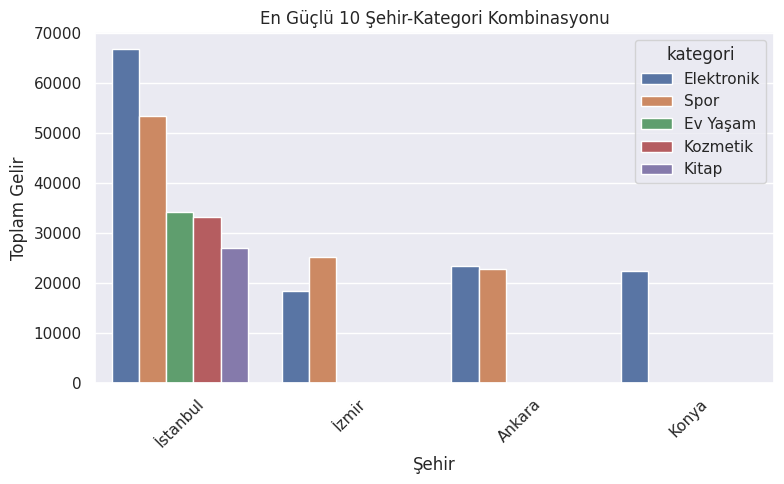

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=en_guclu_10_sehir_kategori,
            x='sehir',
            y='toplam_gelir',
            hue='kategori'
            )
plt.title("En Güçlü 10 Şehir-Kategori Kombinasyonu")
plt.xlabel("Şehir")
plt.ylabel('Toplam Gelir')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### En güçlü kombinasyonu belirleyin.

In [ ]:
en_guclu_10_sehir_kategori.iloc[0]

,0
sehir,İstanbul
kategori,Elektronik
siparis_sayisi,45
toplam_gelir,66731.92
ortalama_siparis_tutari,1482.93
ortalama_musteri_puani,4.18


### Bu bulgunun pazarlama, kampanya veya ürün stratejisi açısından ne anlama gelebileceğini yorumlayın.

En çok getirininin açık ara bir şehirden sağlanması gelirin tek şehire bağımlı olması demektir ki bu pek istenilen bir durum değildir.
İstanbul-Elektronik gibi güçlü kombinasyon korunurken İzmir-spor gibi listenin altında kalmış ama büyüme göstermesi olası kombinasyonlar kampanya/tanıtım gibi çalışmalarla büyümesi desteklenmelidir.